# Airbnb Superhost Readiness Engine

This notebook builds an end-to-end **decision-support workflow** for identifying non-Superhost listings whose observable characteristics resemble those of current Superhosts, then generating targeted support recommendations.

> **Scope:** this is a point-in-time readiness classifier, not a validated forecast of future Superhost conversion. A conversion model would require longitudinal features measured before a future outcome.

> **Reproduction note:** embedded outputs document the original 40-epoch historical run. The refreshed input cells add data-quality checks and early stopping; rerun all cells with the original data to produce a fully synchronized result.

## Business objective
Airbnb benefits when more qualified hosts reach Superhost status because stronger host quality and trust can support better guest experience, stronger conversion, and healthier marketplace performance.

## Modeling objective
Use an **Artificial Neural Network (ANN)** to classify current Superhost status, then combine the score with **gap-based recommendation logic** to produce an analyst-review queue.

## Notebook flow
1. Load and clean the data  
2. Select and preprocess features  
3. Train an ANN classifier  
4. Review learning curves  
5. Tune the decision threshold on the validation set  
6. Evaluate the final model on the test set  
7. Generate a ranked queue of non-Superhosts with Superhost-like characteristics  
8. Save model artifacts and business outputs


In [ ]:
# 1. IMPORTS
import os
import json
import zipfile
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 2. CONFIGURATION
# =========================================================
TRAIN_PATH = "data/Data/airbnb_train.csv"
VAL_PATH = "data/Data/airbnb_validation.csv"
TEST_PATH = "data/Data/airbnb_test.csv"

OUTPUT_DIR = "outputs"
TARGET_COLUMN = "host_is_superhost"
RANDOM_STATE = 42
DEFAULT_THRESHOLD = 0.50
EPOCHS = 40
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 5

os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
# 3. HELPER FUNCTIONS
# =========================================================

def convert_superhost_label(value):
    """Convert host_is_superhost values to binary."""
    if pd.isna(value):
        return None
    value = str(value).strip().lower()
    if value in ["t", "true", "1", "yes"]:
        return 1
    if value in ["f", "false", "0", "no"]:
        return 0
    return None


def clean_percentage(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace("%", "").replace(",", "").strip()
    return pd.to_numeric(val, errors="coerce")


def clean_price(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace("$", "").replace(",", "").strip()
    return pd.to_numeric(val, errors="coerce")


def clean_boolean_like(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in ["t", "true", "yes", "1"]:
        return 1
    if val in ["f", "false", "no", "0"]:
        return 0
    return np.nan


def print_split_summary(df, name):
    print(f"\n{name} shape: {df.shape}")
    if TARGET_COLUMN in df.columns:
        print(f"{name} target distribution:")
        print(df[TARGET_COLUMN].value_counts(normalize=True, dropna=False).rename("proportion"))


def compute_classification_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "balanced_accuracy": float(balanced_acc),
        "specificity": float(specificity),
        "false_negative_rate": float(false_negative_rate),
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
        "y_pred": y_pred
    }


def tune_threshold(y_true, y_prob, thresholds=None, min_precision=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []
    for t in thresholds:
        metrics = compute_classification_metrics(y_true, y_prob, t)
        rows.append({
            "threshold": round(float(t), 2),
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1_score"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "specificity": metrics["specificity"],
            "false_negative_rate": metrics["false_negative_rate"]
        })

    threshold_df = pd.DataFrame(rows)

    if min_precision is not None:
        eligible = threshold_df[threshold_df["precision"] >= min_precision].copy()
        if not eligible.empty:
            best_row = eligible.loc[eligible["recall"].idxmax()]
        else:
            best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
    else:
        best_row = threshold_df.loc[threshold_df["f1"].idxmax()]

    selected_threshold = float(best_row["threshold"])
    return threshold_df, selected_threshold


def assign_priority_tier(prob):
    if prob >= 0.80:
        return "Tier 1 - High potential"
    if prob >= 0.60:
        return "Tier 2 - Moderate potential"
    if prob >= 0.40:
        return "Tier 3 - Developmental"
    return "Low priority"


def build_recommendation(row):
    issues = []
    actions = []

    if "host_response_rate" in row and pd.notna(row["host_response_rate"]) and row["host_response_rate"] < 90:
        gap = 90 - row["host_response_rate"]
        issues.append(f"response rate is {gap:.1f} points below target")
        actions.append("share response-time playbooks and templated message workflows")

    if "review_scores_rating" in row and pd.notna(row["review_scores_rating"]) and row["review_scores_rating"] < 4.7:
        gap = 4.7 - row["review_scores_rating"]
        issues.append(f"overall rating is {gap:.2f} below target")
        actions.append("review guest feedback themes and improve consistency of host experience")

    if "review_scores_communication" in row and pd.notna(row["review_scores_communication"]) and row["review_scores_communication"] < 4.8:
        gap = 4.8 - row["review_scores_communication"]
        issues.append(f"communication score is {gap:.2f} below target")
        actions.append("provide communication templates and faster follow-up guidance")

    if "review_scores_cleanliness" in row and pd.notna(row["review_scores_cleanliness"]) and row["review_scores_cleanliness"] < 4.8:
        gap = 4.8 - row["review_scores_cleanliness"]
        issues.append(f"cleanliness score is {gap:.2f} below target")
        actions.append("share cleaning standards checklist and turnover best practices")

    if "number_of_reviews" in row and pd.notna(row["number_of_reviews"]) and row["number_of_reviews"] < 10:
        gap = 10 - row["number_of_reviews"]
        issues.append(f"review volume is {gap:.0f} reviews below target")
        actions.append("encourage more completed stays and use post-stay review nudges")

    if "availability_365" in row and pd.notna(row["availability_365"]) and row["availability_365"] < 30:
        gap = 30 - row["availability_365"]
        issues.append(f"listing activity is {gap:.0f} days below target")
        actions.append("improve listing activity and calendar management")

    if not issues:
        return (
            "No major measurable deficits detected. Maintain current hosting quality, "
            "monitor consistency, and consider proactive mentorship support."
        )

    return (
        "Key gaps: " + "; ".join(issues) + ". "
        "Suggested actions: " + "; ".join(actions) + "."
    )

In [ ]:
# 4. LOAD DATA
# =========================================================
print("Loading datasets...")

os.makedirs("data", exist_ok=True)

if not os.path.exists(TRAIN_PATH):
    if os.path.exists("/content/Data.zip"):
        print("Extracting Data.zip into data/ ...")
        with zipfile.ZipFile("/content/Data.zip", "r") as zip_ref:
            zip_ref.extractall("data")
    else:
        raise FileNotFoundError(
            "Could not find the train file or Data.zip. "
            "Place Data.zip in the working directory or update the paths."
        )

train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
val_df = pd.read_csv(VAL_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

print_split_summary(train_df, "Train")
print_split_summary(val_df, "Validation")
print_split_summary(test_df, "Test")

Loading datasets...
Extracting Data.zip into data/ ...

Train shape: (25141, 85)
Train target distribution:
host_is_superhost
0    0.805417
1    0.194583
Name: proportion, dtype: float64

Validation shape: (5388, 85)
Validation target distribution:
host_is_superhost
0    0.805308
1    0.194692
Name: proportion, dtype: float64

Test shape: (5388, 85)
Test target distribution:
host_is_superhost
0    0.805494
1    0.194506
Name: proportion, dtype: float64


In [ ]:
# 4A. CHECK FOR HOST OVERLAP ACROSS SPLITS
# =========================================================
# Multiple listings from one host should remain in one split. Overlap can
# make row-level test performance look better than entity-level generalization.
if "host_id" in train_df.columns:
    split_hosts = {
        "train": set(train_df["host_id"].dropna()),
        "validation": set(val_df["host_id"].dropna()),
        "test": set(test_df["host_id"].dropna()),
    }
    overlap_counts = {
        "train_validation": len(split_hosts["train"] & split_hosts["validation"]),
        "train_test": len(split_hosts["train"] & split_hosts["test"]),
        "validation_test": len(split_hosts["validation"] & split_hosts["test"]),
    }
    print("Host overlap across splits:", overlap_counts)
    if any(overlap_counts.values()):
        warnings.warn(
            "Host IDs overlap across data splits. Treat the reported metrics as "
            "row-level estimates and rebuild host-grouped splits before deployment."
        )
else:
    warnings.warn("host_id is unavailable; entity leakage could not be checked.")

In [ ]:
# 5. CLEAN TARGET
# =========================================================
for df in [train_df, val_df, test_df]:
    df[TARGET_COLUMN] = df[TARGET_COLUMN].apply(convert_superhost_label)
    df.dropna(subset=[TARGET_COLUMN], inplace=True)
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

print("\nTarget cleaned successfully.")
print_split_summary(train_df, "Train")
print_split_summary(val_df, "Validation")
print_split_summary(test_df, "Test")


Target cleaned successfully.

Train shape: (25141, 85)
Train target distribution:
host_is_superhost
0    0.805417
1    0.194583
Name: proportion, dtype: float64

Validation shape: (5388, 85)
Validation target distribution:
host_is_superhost
0    0.805308
1    0.194692
Name: proportion, dtype: float64

Test shape: (5388, 85)
Test target distribution:
host_is_superhost
0    0.805494
1    0.194506
Name: proportion, dtype: float64


In [ ]:
# 6. CLEAN COMMON COLUMNS
# =========================================================
all_dfs = [train_df, val_df, test_df]

percentage_cols = ["host_response_rate", "host_acceptance_rate"]
price_cols = ["price"]
boolean_like_cols = [
    "host_identity_verified",
    "instant_bookable",
    "has_availability"
]

for df in all_dfs:
    for col in percentage_cols:
        if col in df.columns:
            df[col] = df[col].apply(clean_percentage)

    for col in price_cols:
        if col in df.columns:
            df[col] = df[col].apply(clean_price)

    for col in boolean_like_cols:
        if col in df.columns:
            df[col] = df[col].apply(clean_boolean_like)

    if "bathrooms" not in df.columns and "bathrooms_text" in df.columns:
        df["bathrooms"] = (
            df["bathrooms_text"]
            .astype(str)
            .str.extract(r"(\d+(\.\d+)?)")[0]
            .astype(float)
        )

print("Common column cleaning complete.")

Common column cleaning complete.


In [ ]:
# 7. FEATURE SELECTION
# =========================================================
candidate_numeric_features = [
    "host_response_rate",
    "host_acceptance_rate",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "price",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms"
]

candidate_categorical_features = [
    "host_response_time",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "host_identity_verified",
    "instant_bookable",
    "has_availability"
]

present_numeric_features = [col for col in candidate_numeric_features if col in train_df.columns]
present_categorical_features = [col for col in candidate_categorical_features if col in train_df.columns]

# Exclude all-missing training columns explicitly instead of relying on an
# imputer warning and a silent dimensionality change.
all_missing_features = [
    col
    for col in present_numeric_features + present_categorical_features
    if train_df[col].notna().sum() == 0
]
numeric_features = [col for col in present_numeric_features if col not in all_missing_features]
categorical_features = [col for col in present_categorical_features if col not in all_missing_features]
selected_features = numeric_features + categorical_features

if not selected_features:
    raise ValueError("No usable features were found in the dataset.")

if all_missing_features:
    warnings.warn(f"Excluded all-missing training features: {all_missing_features}")

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal selected features:", len(selected_features))

Numeric features:
['host_response_rate', 'host_acceptance_rate', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']

Categorical features:
['host_response_time', 'room_type', 'property_type', 'neighbourhood_cleansed', 'host_identity_verified', 'instant_bookable', 'has_availability']

Total selected features: 34


In [ ]:
# 8. BUILD X AND y
# =========================================================
X_train = train_df[selected_features].copy()
X_val = val_df[selected_features].copy()
X_test = test_df[selected_features].copy()

y_train = train_df[TARGET_COLUMN].values
y_val = val_df[TARGET_COLUMN].values
y_test = test_df[TARGET_COLUMN].values

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

X_train shape: (25141, 34)
X_val shape  : (5388, 34)
X_test shape : (5388, 34)


In [ ]:
# 9. PREPROCESS DATA
# =========================================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrices to dense arrays
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_val_processed = X_val_processed.toarray()
    X_test_processed = X_test_processed.toarray()

input_dim = X_train_processed.shape[1]
print("Processed input dimension:", input_dim)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['host_response_rate' 'host_acceptance_rate' 'price']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['host_response_time' 'instant_bookable']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['host_response_rate' 'host_acceptance_rate' 'price']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['host_response_time' 'instant_bo

Processed input dimension: 323


In [ ]:
# 10. BUILD ANN MODEL
# =========================================================
model = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,841 (202.50 KB)

 Trainable params: 51,841 (202.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 11. TRAIN MODEL
# =========================================================
early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
)

history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/40
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8383 - auc: 0.8253 - loss: 0.3778 - precision: 0.6831 - recall: 0.3150 - val_accuracy: 0.8578 - val_auc: 0.8747 - val_loss: 0.3287 - val_precision: 0.6946 - val_recall: 0.4814
Epoch 2/40
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8626 - auc: 0.8761 - loss: 0.3259 - precision: 0.7211 - recall: 0.4794 - val_accuracy: 0.8682 - val_auc: 0.8885 - val_loss: 0.3094 - val_precision: 0.7439 - val_recall: 0.4929
Epoch 3/40
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8737 - auc: 0.8945 - loss: 0.3037 - precision: 0.7476 - recall: 0.5298 - val_accuracy: 0.8769 - val_auc: 0.9002 - val_loss: 0.2940 - val_precision: 0.7419 - val_recall: 0.5643
Epoch 4/40
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8812 - auc: 0.9076 - loss: 0.2855 - precision: 0.7549 - recall: 0.5769 - val_accuracy: 0.8801 - val_auc: 0.9054 - val_loss: 0.2895 - val_precision: 0.7522 - val_recall: 0.5729
Epoch 5/40
393/393 ━━━━━━━━━━━━

## Training history

Training monitors validation AUC and restores the best weights when performance stops improving. The embedded historical output predates this safeguard and shows why it is needed: training performance continued improving while validation performance declined.

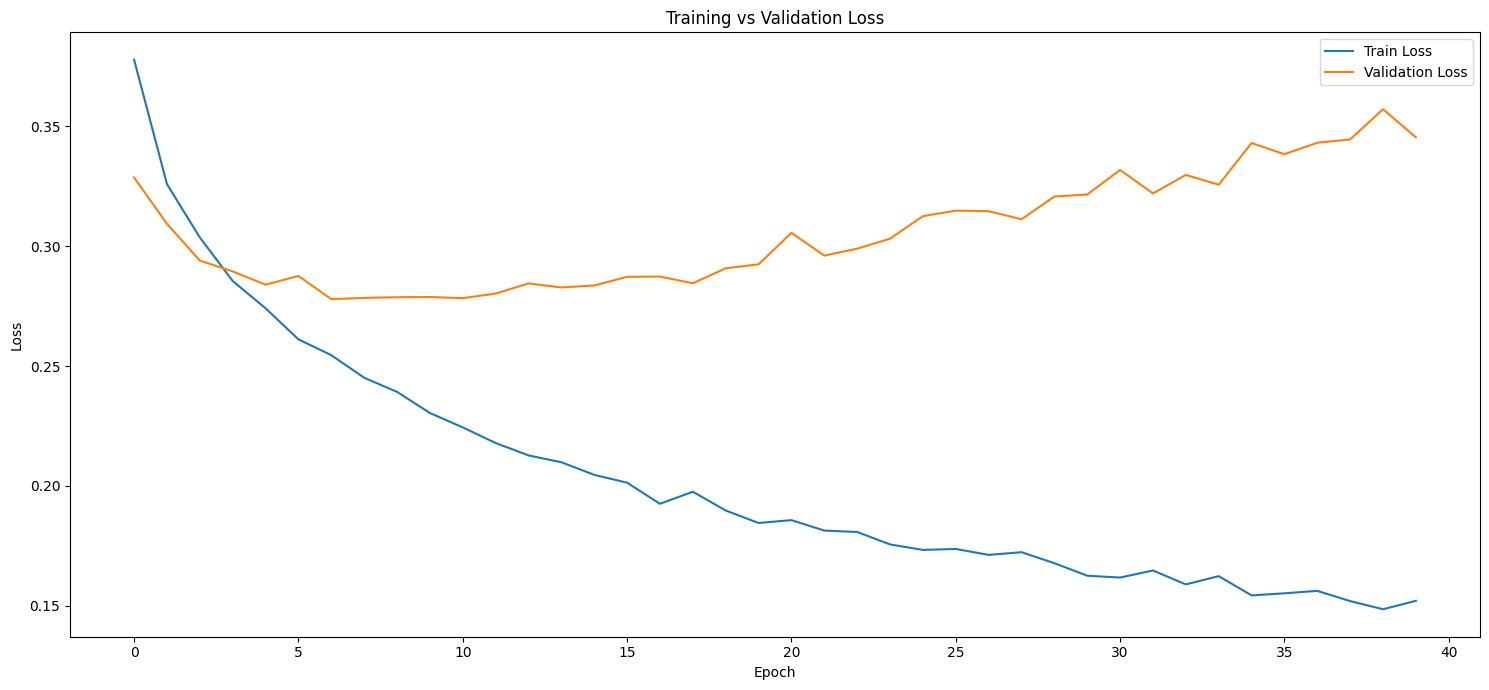

In [ ]:
import matplotlib.pyplot as plt

# 12. PLOT TRAINING CURVES - LOSS
# =========================================================
plt.figure(figsize=(15, 7))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

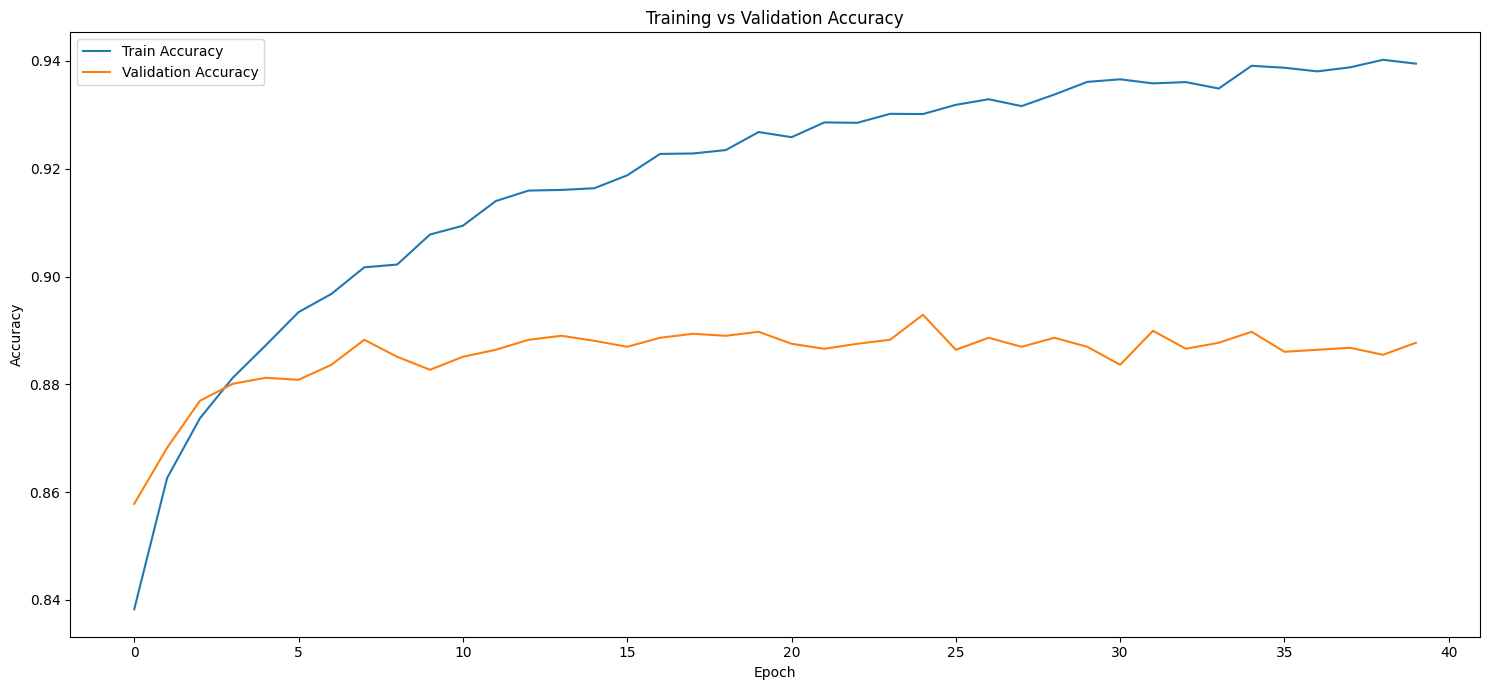

In [ ]:
# 13. PLOT TRAINING CURVES - ACCURACY
plt.figure(figsize=(15, 7))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Threshold tuning on the validation set

Because this workflow surfaces non-Superhost rows for analyst review, threshold choice matters.  
Instead of defaulting to 0.50, we compare multiple thresholds and choose one based on validation performance.

In [ ]:
# 14. THRESHOLD TUNING ON VALIDATION SET
# =========================================================
y_val_prob = model.predict(X_val_processed).ravel()

threshold_df, selected_threshold = tune_threshold(
    y_true=y_val,
    y_prob=y_val_prob,
    thresholds=np.arange(0.10, 0.91, 0.05),
    min_precision=0.50
)

print("Threshold comparison table:")
print(threshold_df)

print(f"\nSelected threshold: {selected_threshold:.2f}")
THRESHOLD = selected_threshold

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Threshold comparison table:
    threshold  accuracy  precision    recall        f1  balanced_accuracy  \
0        0.10  0.818671   0.521661  0.826501  0.639616           0.821640   
1        0.15  0.845026   0.575779  0.775024  0.660707           0.818487   
2        0.20  0.862287   0.622311  0.744519  0.677951           0.817638   
3        0.25  0.871195   0.654752  0.715920  0.683971           0.812327   
4        0.30  0.876578   0.679775  0.692088  0.685876           0.806634   
5        0.35  0.880290   0.701195  0.671115  0.685826           0.800987   
6        0.40  0.885115   0.726793  0.656816  0.690035           0.798562   
7        0.45  0.887528   0.743674  0.644423  0.690501           0.795362   
8        0.50  0.887713   0.758140  0.621544  0.683080           0.786804   
9        0.55  0.889198   0.777641  0.603432  0.679549           0.780859   
10       0.60  0.888641   0.791938  0.580553  0.669967           0.771839   
11     

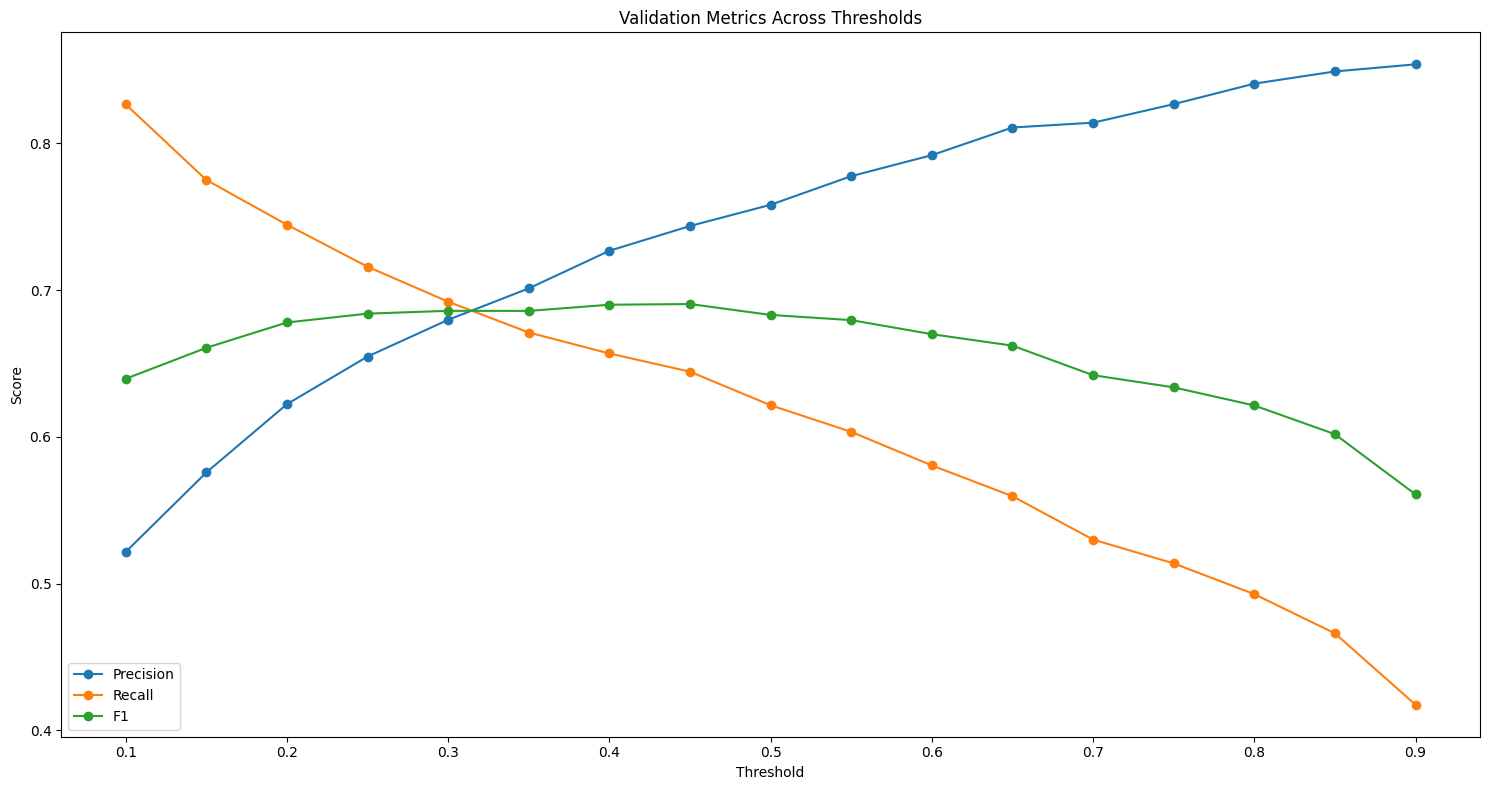

In [ ]:
import matplotlib.pyplot as plt

# 15. PLOT THRESHOLD METRICS
plt.figure(figsize=(15, 8))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Metrics Across Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

## Final evaluation on the test set

After threshold tuning on the validation set, we lock the selected threshold and evaluate on the untouched test set.

In [ ]:
# 16. FINAL TEST EVALUATION
# =========================================================
y_test_prob = model.predict(X_test_processed).ravel()
test_metrics = compute_classification_metrics(y_test, y_test_prob, THRESHOLD)
y_test_pred = test_metrics["y_pred"]

print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
for key in [
    "threshold", "accuracy", "precision", "recall", "f1_score",
    "roc_auc", "pr_auc", "balanced_accuracy", "specificity", "false_negative_rate"
]:
    print(f"{key:20s}: {test_metrics[key]:.4f}")

print("\nConfusion Matrix:")
print(np.array(test_metrics["confusion_matrix"]))

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

TEST SET EVALUATION
threshold           : 0.1000
accuracy            : 0.8226
precision           : 0.5282
recall              : 0.8225
f1_score            : 0.6433
roc_auc             : 0.8960
pr_auc              : 0.7589
balanced_accuracy   : 0.8225
specificity         : 0.8226
false_negative_rate : 0.1775

Confusion Matrix:
[[3570  770]
 [ 186  862]]


In [ ]:
# 17. CLASSIFICATION REPORT
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      4340
           1       0.53      0.82      0.64      1048

    accuracy                           0.82      5388
   macro avg       0.74      0.82      0.76      5388
weighted avg       0.87      0.82      0.84      5388



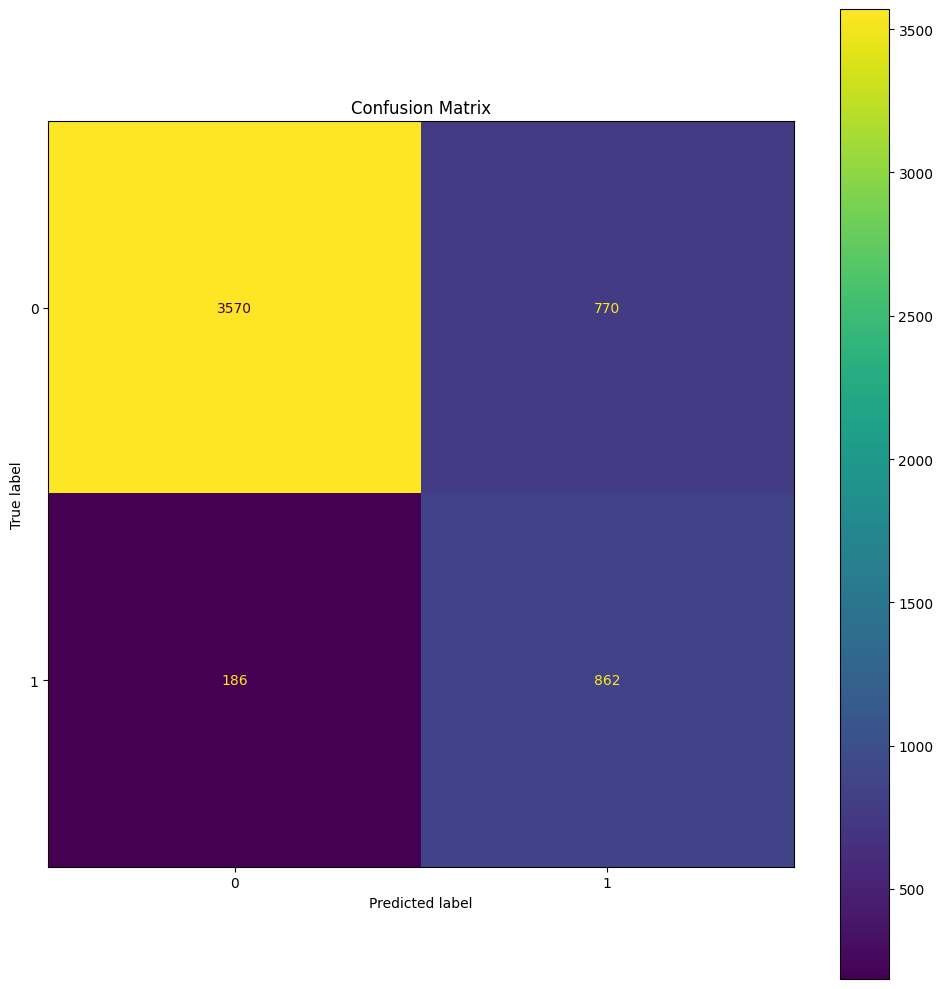

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import confusion_matrix

# 18. PLOT CONFUSION MATRIX
# =========================================================
fig_cm, ax_cm = plt.subplots(figsize=(10, 10)) # Increased figsize
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred))
disp.plot(ax=ax_cm)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

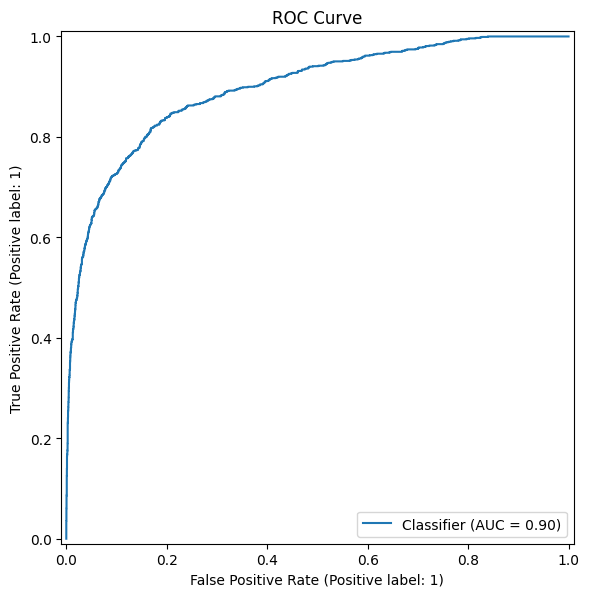

In [ ]:
# 19. PLOT ROC CURVE
fig_roc, ax_roc = plt.subplots(figsize=(6, 12))
RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=ax_roc)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

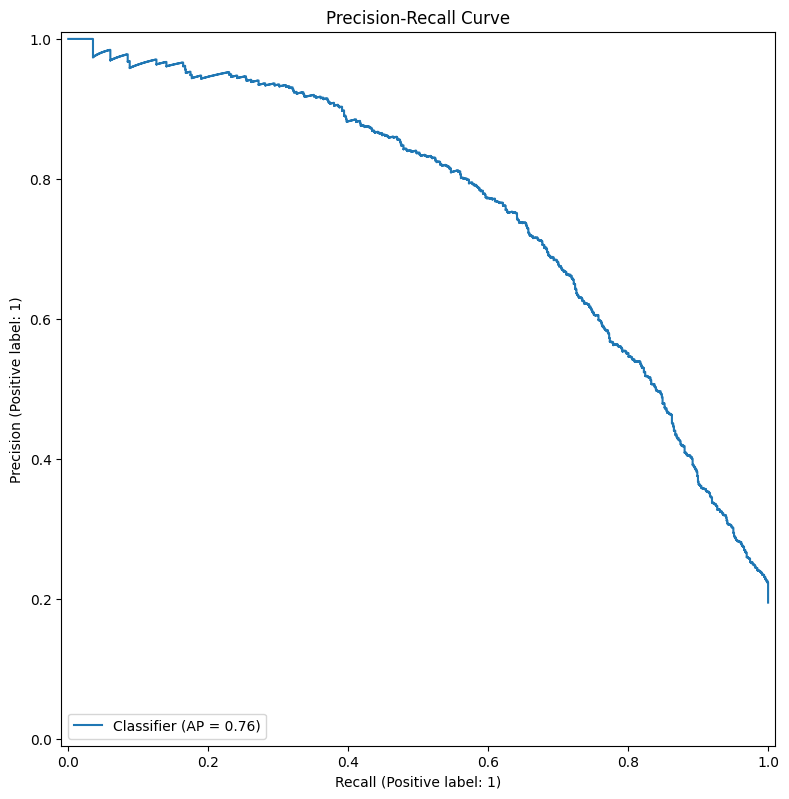

In [ ]:
# 20. PLOT PRECISION-RECALL CURVE
fig_pr, ax_pr = plt.subplots(figsize=(8, 14)) # Increased figsize
PrecisionRecallDisplay.from_predictions(y_test, y_test_prob, ax=ax_pr)
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

## Candidate engine output

The business engine should not simply classify everyone.  
It should focus on **non-Superhosts** and rank those with the highest probability of converting, then attach actionable recommendations.

In [ ]:
# 21. BUILD CANDIDATE QUEUE FOR ACTION
# =========================================================
results_df = test_df.copy()
results_df["predicted_probability"] = y_test_prob
results_df["predicted_superhost"] = y_test_pred

# Focus on non-Superhosts only
candidate_df = results_df[results_df[TARGET_COLUMN] == 0].copy()

# Rank and label by actionability
candidate_df["priority_tier"] = candidate_df["predicted_probability"].apply(assign_priority_tier)
candidate_df["recommendation_message"] = candidate_df.apply(build_recommendation, axis=1)

candidate_df = candidate_df.sort_values(
    by=["predicted_probability"],
    ascending=False
).reset_index(drop=True)

preview_cols = [
    col for col in [
        TARGET_COLUMN,
        "predicted_probability",
        "priority_tier",
        "recommendation_message"
    ] if col in candidate_df.columns
]

print("Top ranked candidate queue preview:")
print(candidate_df[preview_cols].head(15))

### Tier 1 - High Potential Candidates

In [ ]:
# 22. DISPLAY TIER 1 CANDIDATES
tier1_candidates = candidate_df[candidate_df['priority_tier'] == 'Tier 1 - High potential']
print(f"Number of Tier 1 candidates: {len(tier1_candidates)}")
display(tier1_candidates[preview_cols].head())

### Tier 2 - Moderate Potential Candidates

In [ ]:
# 23. DISPLAY TIER 2 CANDIDATES
tier2_candidates = candidate_df[candidate_df['priority_tier'] == 'Tier 2 - Moderate potential']
print(f"Number of Tier 2 candidates: {len(tier2_candidates)}")
display(tier2_candidates[preview_cols].head())

### Tier 3 - Developmental Candidates

In [ ]:
# 24. DISPLAY TIER 3 CANDIDATES
tier3_candidates = candidate_df[candidate_df['priority_tier'] == 'Tier 3 - Developmental']
print(f"Number of Tier 3 candidates: {len(tier3_candidates)}")
display(tier3_candidates[preview_cols].head())

In [ ]:
# 25. SAVE OUTPUTS AND ARTIFACTS
# =========================================================
metrics_to_save = {
    key: value for key, value in test_metrics.items() if key not in ["y_pred"]
}
metrics_to_save.update({
    "train_rows": int(len(train_df)),
    "validation_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "input_dimension": int(input_dim),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "all_selected_features": selected_features
})

with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics_to_save, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "selected_threshold.json"), "w") as f:
    json.dump({"threshold": float(THRESHOLD)}, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "features_used.json"), "w") as f:
    json.dump({
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "all_selected_features": selected_features
    }, f, indent=4)

model.save(os.path.join(OUTPUT_DIR, "superhost_ann_model.keras"))
joblib.dump(preprocessor, os.path.join(OUTPUT_DIR, "preprocessor.joblib"))

threshold_df.to_csv(os.path.join(OUTPUT_DIR, "threshold_tuning_results.csv"), index=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, "all_test_predictions.csv"), index=False)
candidate_df.to_csv(os.path.join(OUTPUT_DIR, "superhost_candidate_queue.csv"), index=False)

# Save static plots
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"))
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_curve.png"))
plt.close()

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred))
disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.close()

RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title("ROC Curve")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"))
plt.close()

PrecisionRecallDisplay.from_predictions(y_test, y_test_prob)
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pr_curve.png"))
plt.close()

print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: outputs


## Final note

This notebook now supports both the **modeling** side and the **business action** side of the project:
- ANN-based probability scoring
- validation-based threshold tuning
- business-aligned classification metrics
- ranked non-Superhost readiness queue
- saved experimental artifacts for reuse

The outputs support exploratory decision analysis. They should not be interpreted as forecasts, causal recommendations, or deployment-ready decisions without longitudinal, grouped, calibrated, and subgroup-aware validation.

For the current leakage-resistant, host-grouped model comparison, see `reports/benchmark.md` and `src/train_baselines.py`. The gradient-boosting baseline is now the project's recommended model; this ANN remains as the documented historical master's-project approach.
